# M4 — arm C (DPM-Solver-1 + authors' code) + Gate G1

Arm C integrates the same PF-ODE exactly on its linear part (paper section 3),
marched on a grid uniform in $\lambda$. Two implementations, both tested here:

* **hand-written** (`src/dpm.py`) — `dpm_solver_1` (paper eq 3.7) and
  `ddim_step` (paper eq 4.1, original DDIM form). These are the *same*
  algebraic identity written two different ways.
* **the authors' own code** (`src/arm_c.py`), wrapping
  `third_party/dpm_solver_pytorch.py` unmodified, driven by the analytic noise
  oracle instead of a network.

## Gate G1 — the critical checkpoint

Per the guide, we do not build past this gate until both hold:

1. `dpm_solver_1` ≡ `ddim_step`, marched over a shared $\lambda$-grid:
   $\max|x_a - x_b| < 10^{-14}$. If this fails, $\lambda$ handling is broken.
2. `dpm_solver_1` measures as first order on Tier 1 (log-log slope in
   $[0.85, 1.15]$). If this fails, the error-measurement machinery is broken.

In [1]:
import sys, pathlib, subprocess
import numpy as np
import matplotlib.pyplot as plt

p = pathlib.Path.cwd()
while not (p / "pyproject.toml").exists() and p != p.parent:
    p = p.parent
ROOT = p
sys.path.insert(0, str(ROOT))

from src.schedule import t_of_lmbda
from src.grids import grid_lambda
from src.testbeds import GaussianTier1
from src.dpm import dpm_solver_1, ddim_step, march
from src.arm_c import sample_dpm_solver

FIGDIR = ROOT / "figures"; FIGDIR


WindowsPath('H:/My Drive/BUET/BOOKS 4-1/CSE 401/Sessional/NUMERICAL-PROJECT/figures')

## 1. Gate G1, part 1 — dpm_solver_1 ≡ ddim_step

Two formulas (paper eq 3.7 and eq 4.1), marched over the same $\lambda$-grid,
must agree to machine precision.

In [2]:
def t_grid_for(T, t_end, n):
    tg = t_of_lmbda(grid_lambda(T, t_end, n))
    tg[0], tg[-1] = T, t_end
    return tg

tb = GaussianTier1(kappa=100.0, d=4, seed=0)
xT = tb.x_T(5)
T, t_end = 1.0, 1e-3
tg = t_grid_for(T, t_end, 40)

xa = march(dpm_solver_1, tb.eps, xT, tg)
xb = march(ddim_step, tb.eps, xT, tg)
gap = np.max(np.abs(xa - xb))
print("max|dpm_solver_1 - ddim_step| =", gap)
assert gap < 1e-14
print("GATE G1 (1/2): PASS")


max|dpm_solver_1 - ddim_step| = 5.551115123125783e-16
GATE G1 (1/2): PASS


## 2. Gate G1, part 2 — dpm_solver_1 is first order

measured slope = 0.9898515527386573
GATE G1 (2/2): PASS


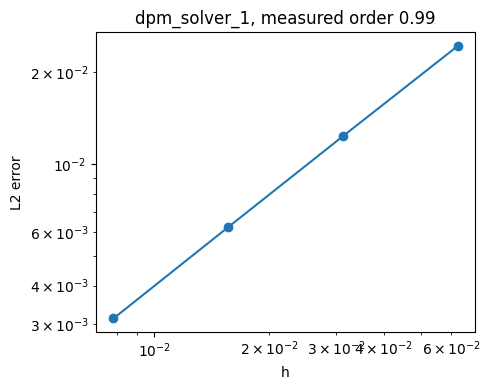

In [3]:
def slope(ns, errs):
    hs = 1.0 / np.asarray(ns, dtype=np.float64)
    errs = np.asarray(errs, dtype=np.float64)
    A = np.vstack([np.log(hs), np.ones_like(hs)]).T
    s, _ = np.linalg.lstsq(A, np.log(errs), rcond=None)[0]
    return float(s)

tb2 = GaussianTier1(kappa=10.0, d=3, seed=0)
xT2 = tb2.x_T(5)
T, T_END = 1.0, 0.2
ref = tb2.exact(xT2, T, T_END)

ns = [16, 32, 64, 128]
errs = []
for n in ns:
    tg = t_grid_for(T, T_END, n)
    xf = march(dpm_solver_1, tb2.eps, xT2, tg)
    errs.append(np.sqrt(np.mean((xf - ref) ** 2)))

m = slope(ns, errs)
print("measured slope =", m)
assert 0.85 <= m <= 1.15
print("GATE G1 (2/2): PASS")

fig, ax = plt.subplots(figsize=(5, 4))
ax.loglog(1.0 / np.asarray(ns), errs, "o-")
ax.set_xlabel("h"); ax.set_ylabel("L2 error"); ax.set_title(f"dpm_solver_1, measured order {m:.2f}")
fig.tight_layout(); fig.savefig(FIGDIR / "04_gate_g1_order1.png", dpi=130)


## 3. The authors' code, driven by the analytic oracle

`src/arm_c.py` wraps `third_party/dpm_solver_pytorch.py` with
`algorithm_type="dpmsolver"` (the paper's original parameterisation, matching
`dpm_solver_1` exactly -- not the data-prediction `"dpmsolver++"` default),
`method="singlestep_fixed"`, `skip_type="logSNR"`. First: order=1 through the
wrapper must reproduce the hand-written `dpm_solver_1` on the same grid.

In [4]:
n = 32
xf_wrap, nfe = sample_dpm_solver(tb.eps, xT, T, T_END, order=1, steps=n)
tg = t_grid_for(T, T_END, n)
xf_hand = march(dpm_solver_1, tb.eps, xT, tg)
print("nfe =", nfe, " max|wrapper - hand-written| =", np.max(np.abs(xf_wrap - xf_hand)))


nfe = 32  max|wrapper - hand-written| = 7.771561172376096e-16


## 4. Orders 1, 2, 3 through the wrapper

Real NFE for `singlestep_fixed` is `(steps // order) * order`, not `steps` --
recorded explicitly, not assumed.

order=1  measured slope=0.990
order=2  measured slope=2.045


order=3  measured slope=3.149


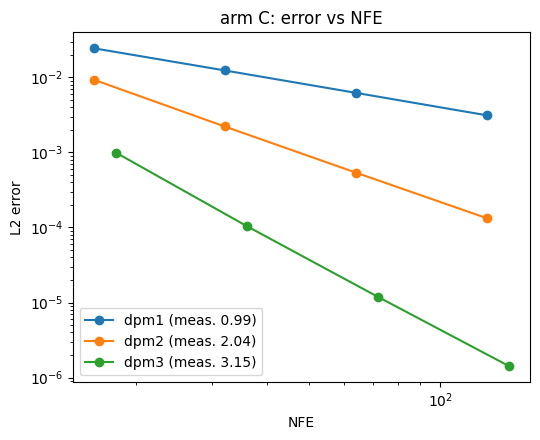

In [5]:
CASES = {1: [16, 32, 64, 128], 2: [16, 32, 64, 128], 3: [18, 36, 72, 144]}
results = {}
for order, steps_list in CASES.items():
    errs = []
    for steps in steps_list:
        xf, nfe = sample_dpm_solver(tb2.eps, xT2, T, T_END, order=order, steps=steps)
        assert nfe == (steps // order) * order
        errs.append(np.sqrt(np.mean((xf - ref) ** 2)))
    m = slope(steps_list, errs)
    results[order] = (steps_list, errs, m)
    print(f"order={order}  measured slope={m:.3f}")

fig, ax = plt.subplots(figsize=(5.5, 4.5))
for order, (steps_list, errs, m) in results.items():
    nfes = [(s // order) * order for s in steps_list]
    ax.loglog(nfes, errs, "o-", label=f"dpm{order} (meas. {m:.2f})")
ax.set_xlabel("NFE"); ax.set_ylabel("L2 error"); ax.set_title("arm C: error vs NFE"); ax.legend()
fig.tight_layout(); fig.savefig(FIGDIR / "04_arm_c_orders.png", dpi=130)


## 5. Validation — run the unit tests

In [6]:
out = subprocess.run(
    [sys.executable, "-m", "pytest", "tests/test_gate_g1.py", "tests/test_arm_c.py", "-q"],
    cwd=ROOT, capture_output=True, text=True,
)
print(out.stdout); print(out.stderr)
assert out.returncode == 0, "arm C / Gate G1 tests failed"
print("M4 validation: PASS")


.......                                                                  [100%]


M4 validation: PASS
